# Spiking Neural Network Transformer for Time Series Forecasting
## Dataset: Dow Jones Industrial Index

**Architecture:** Spike-Driven Transformer (Yao et al., 2024)
adapted for univariate time series forecasting.

**Reference:** *Spike-driven Transformer V2: Meta Spiking Neural Network Architecture
Inspiring the Design of Next-generation Neuromorphic Chips* — ICLR 2024

This notebook is a **controlled architectural substitution** of the LSTM-SNP model.
All preprocessing, training protocol, and evaluation methodology are identical
to the LSTM-SNP experiments — only the model architecture changes.

### Key Equations (from the paper)

**LIF Neuron (Eq 1-3):**
- $U[t] = H[t-1] + X[t]$  — membrane potential accumulation
- $S[t] = \text{Hea}(U[t] - u_{th})$  — spike generation (Heaviside)
- $H[t] = V_{reset} \cdot S[t] + (\beta \cdot U[t]) \cdot (1 - S[t])$  — temporal output with reset

**SDSA (Eq 14):**
- $\text{SDSA}(Q, K, V) = \mathcal{SN}(\text{SUM}_c(Q_S \otimes K_S)) \otimes V_S$

**Membrane Shortcut (Eq 9, 11):**
- $U'_l = \text{SDSA}(S_{l-1}) + U_{l-1}$
- $S_l = \mathcal{SN}(\text{MLP}(S'_l) + U'_l)$


In [11]:
# ============================================================
# ALL IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if hasattr(torch.backends, 'mps'):
    print(f"MPS available: {torch.backends.mps.is_available()}")

PyTorch version: 2.10.0
CUDA available: False
MPS available: True


In [12]:
# ============================================================
# PREPROCESSING — Identical to LSTM-SNP Pipeline
# ============================================================
# 1. First-order differencing
# 2. Lag-1 supervised learning format
# 3. Train-test split (last 60 = test)
# 4. MinMaxScaler [-1, 1] (fit on train only)
# 5. Reshape to (samples, 1, 1)

def difference(dataset, interval=1):
    """First-order differencing: diff(t) = raw(t) - raw(t-interval)"""
    diff = []
    for i in range(interval, len(dataset)):
        value = dataset[i] - dataset[i - interval]
        diff.append(value)
    return np.array(diff)


def timeseries_to_supervised(data, lag=1):
    """Convert to supervised format: X(t)=data(t-lag), y(t)=data(t). NaN filled with 0."""
    df = pd.DataFrame(data)
    columns = [df.shift(i) for i in range(1, lag + 1)]
    columns.append(df)
    df = pd.concat(columns, axis=1)
    df.fillna(0, inplace=True)
    return df.values


def prepare_data(raw_values, n_test=60):
    """Full preprocessing pipeline (identical to LSTM-SNP notebooks)."""
    # Step 1: First-order differencing
    diff_values = difference(raw_values, 1)

    # Step 2: Convert to supervised format (lag=1)
    supervised = timeseries_to_supervised(diff_values, 1)

    # Step 3: Train-test split
    train, test = supervised[:-n_test], supervised[-n_test:]

    # Step 4: Scale to [-1, 1] — fit on train only
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaler.fit(train)
    train_scaled = scaler.transform(train)
    test_scaled = scaler.transform(test)

    # Step 5: Split into X, y
    X_train, y_train = train_scaled[:, 0:-1], train_scaled[:, -1]
    X_test, y_test = test_scaled[:, 0:-1], test_scaled[:, -1]

    # Step 6: Reshape X for model input: (samples, 1, features=1)
    X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

    return X_train, y_train, X_test, y_test, scaler, raw_values

In [13]:
# ============================================================
# SPIKING NEURON — Leaky Integrate-and-Fire (LIF)
# ============================================================
# Faithfully implements Equations 1-3 from the Spike-Driven Transformer paper:
#
#   Eq 1: U[t] = H[t-1] + X[t]                              (membrane potential)
#   Eq 2: S[t] = Hea(U[t] - u_th)                           (spike generation)
#   Eq 3: H[t] = V_reset * S[t] + (β * U[t]) * (1 - S[t])  (temporal output)
#
# Where:
#   U[t] = membrane potential at timestep t
#   H[t] = temporal output (decayed potential or reset)
#   S[t] = binary spike output {0, 1}
#   β < 1 = decay factor
#   u_th = firing threshold
#   V_reset = reset potential after spike
#   Hea(·) = Heaviside step function
#
# Surrogate gradient (for backpropagation):
#   ∂S/∂U ≈ 1 / (1 + α|U - u_th|)²


class SurrogateHeaviside(torch.autograd.Function):
    """Heaviside step with surrogate gradient for backpropagation."""
    @staticmethod
    def forward(ctx, input, alpha):
        ctx.save_for_backward(input)
        ctx.alpha = alpha
        return (input >= 0).float()

    @staticmethod
    def backward(ctx, grad_output):
        (input,) = ctx.saved_tensors
        alpha = ctx.alpha
        grad_input = grad_output / (1 + alpha * input.abs()) ** 2
        return grad_input, None


def surrogate_heaviside(x, alpha=2.0):
    return SurrogateHeaviside.apply(x, alpha)


class LIFNeuron(nn.Module):
    """
    Leaky Integrate-and-Fire neuron (Eq 1-3 from the paper).

    Processes input across T spiking timesteps.
    Membrane potential H is maintained across timesteps, reset per forward call.
    """
    def __init__(self, beta=0.5, v_th=0.5, v_reset=0.0, alpha=2.0):
        super().__init__()
        self.beta = beta        # decay factor (β < 1)
        self.v_th = v_th        # firing threshold (u_th)
        self.v_reset = v_reset  # reset potential (V_reset)
        self.alpha = alpha      # surrogate gradient sharpness

    def forward(self, x_seq):
        """
        x_seq: (batch, T, features) — input current across T timesteps.
        Returns: (batch, T, features) — binary spike output.
        """
        batch, T, features = x_seq.shape
        device = x_seq.device

        H = torch.zeros(batch, features, device=device)  # temporal output H[t-1]
        spikes = []

        for t in range(T):
            # Eq 1: U[t] = H[t-1] + X[t]
            U = H + x_seq[:, t, :]

            # Eq 2: S[t] = Hea(U[t] - u_th)
            S = surrogate_heaviside(U - self.v_th, self.alpha)

            # Eq 3: H[t] = V_reset * S[t] + (β * U[t]) * (1 - S[t])
            H = self.v_reset * S + (self.beta * U) * (1 - S.detach())

            spikes.append(S)

        return torch.stack(spikes, dim=1)  # (batch, T, features)

In [14]:
# ============================================================
# SPIKE-DRIVEN SELF-ATTENTION (SDSA)
# ============================================================
# Implements Equations 14-16 from the Spike-Driven Transformer paper.
#
# Standard Self-Attention (Eq 13):
#   VSA(Q,K,V) = softmax(QK^T / √d) · V     → O(N²D + N²D)
#
# Spike-Driven Self-Attention (Eq 14):
#   SDSA(Q,K,V) = SN(SUM_c(Q_S ⊗ K_S)) ⊗ V_S
#
# Where:
#   Q, K, V = linear projections of spike input S (float-point)
#   Q_S, K_S, V_S = SN(Q), SN(K), SN(V)  (converted to spikes)
#   ⊗ = Hadamard product (element-wise multiplication)
#   SUM_c = column sum (sum over token/temporal dimension)
#   SN = Spiking Neuron (LIF)
#
# The key insight: since spikes are binary {0, 1}, the Hadamard product
# Q_S ⊗ K_S is equivalent to a mask operation. SUM_c aggregates activity
# across tokens to produce a D-dimensional feature attention mask.
# This mask gates V_S, selecting relevant feature channels.
#
# Computational complexity: O(ND) — linear in both N and D.


class SpikeDrivenSelfAttention(nn.Module):
    """
    SDSA adapted for 1D time series.

    Input: spike tensor S ∈ {0,1}^(batch, T, D)
    Output: spike-gated features ∈ R^(batch, T, D)
    """
    def __init__(self, d_model, n_heads, beta=0.5, v_th=0.5):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        # Linear projections (float-point, Eq 14 setup)
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.proj = nn.Linear(d_model, d_model)

        # Spiking neurons to convert projections to spike tensors
        self.sn_q = LIFNeuron(beta=beta, v_th=v_th)
        self.sn_k = LIFNeuron(beta=beta, v_th=v_th)
        self.sn_v = LIFNeuron(beta=beta, v_th=v_th)
        # SN for attention mask (Eq 14: SN after SUM_c)
        self.sn_attn = LIFNeuron(beta=beta, v_th=v_th)

    def forward(self, spike_input):
        """
        spike_input: (batch, T, d_model) — spike tensor from previous layer.
        """
        batch, T, D = spike_input.shape

        # Linear projections (float-point)
        Q = self.W_Q(spike_input)
        K = self.W_K(spike_input)
        V = self.W_V(spike_input)

        # Convert to spike tensors via SN (spiking neuron)
        Q_S = self.sn_q(Q)  # (batch, T, D)
        K_S = self.sn_k(K)
        V_S = self.sn_v(V)

        # ── SDSA Computation (Eq 14) ──
        # Step 1: Hadamard product Q_S ⊗ K_S
        QK = Q_S * K_S  # (batch, T, D) — element-wise, spike masking

        # Step 2: SUM_c — sum over temporal dimension (columns)
        # Produces D-dimensional attention vector per batch
        attn_sum = QK.sum(dim=1, keepdim=True)  # (batch, 1, D)

        # Step 3: SN — convert attention map to binary mask
        attn_mask = self.sn_attn(attn_sum)  # (batch, 1, D)

        # Step 4: Hadamard with V_S — gate value spikes by attention mask
        output = attn_mask * V_S  # (batch, T, D) — broadcast across T

        # Output projection
        return self.proj(output)

In [15]:
# ============================================================
# SPIKING TRANSFORMER BLOCK with Membrane Shortcuts
# ============================================================
# Implements Equations 8-12 from the paper.
#
# The block consists of SDSA + MLP with Membrane Shortcuts (MS):
#
#   Eq 8:  S_0 = SN(U_0)                          (initial spikes)
#   Eq 9:  U'_l = SDSA(S_{l-1}) + U_{l-1}         (MS on SDSA)
#   Eq 10: S'_l = SN(U'_l)
#   Eq 11: S_l = SN(MLP(S'_l) + U'_l)             (MS on MLP)
#   Eq 12: Y = CH(GAP(S_L))                        (output)
#
# Membrane Shortcut (MS) connects membrane potentials between layers,
# ensuring binary spikes are maintained throughout (unlike SEW shortcut).


class SpikingMLP(nn.Module):
    """Simple MLP for the spiking transformer block."""
    def __init__(self, d_model, ff_dim):
        super().__init__()
        self.fc1 = nn.Linear(d_model, ff_dim)
        self.fc2 = nn.Linear(ff_dim, d_model)

    def forward(self, x):
        return self.fc2(F.gelu(self.fc1(x)))


class SpikingTransformerBlock(nn.Module):
    """
    Single Spiking Transformer block with Membrane Shortcuts (Eq 9-11).

    Takes both spike tensor S and membrane potential U from previous layer.
    Returns updated spike tensor and membrane potential.
    """
    def __init__(self, d_model, n_heads, ff_dim, beta=0.5, v_th=0.5):
        super().__init__()
        self.sdsa = SpikeDrivenSelfAttention(d_model, n_heads, beta, v_th)
        self.mlp = SpikingMLP(d_model, ff_dim)

        # SN after SDSA + membrane shortcut (Eq 10)
        self.sn_post_sdsa = LIFNeuron(beta=beta, v_th=v_th)
        # SN after MLP + membrane shortcut (Eq 11)
        self.sn_post_mlp = LIFNeuron(beta=beta, v_th=v_th)

    def forward(self, S_prev, U_prev):
        """
        S_prev: (batch, T, D) — spike tensor from previous layer
        U_prev: (batch, T, D) — membrane potential from previous layer
        """
        # Eq 9: U'_l = SDSA(S_{l-1}) + U_{l-1}  (Membrane Shortcut)
        U_prime = self.sdsa(S_prev) + U_prev

        # Eq 10: S'_l = SN(U'_l)
        S_prime = self.sn_post_sdsa(U_prime)

        # Eq 11: S_l = SN(MLP(S'_l) + U'_l)  (Membrane Shortcut on MLP)
        S_l = self.sn_post_mlp(self.mlp(S_prime) + U_prime)

        return S_l, U_prime

In [16]:
# ============================================================
# SPIKING TRANSFORMER FORECASTER — Complete Model
# ============================================================
# Adapted from the Spike-Driven Transformer for univariate time series.
#
# Architecture:
#   1. Input Projection: scalar → d_model (replaces SPS from the paper)
#   2. Temporal Expansion: repeat across T spiking timesteps
#   3. Initial SN: S_0 = SN(U_0) (Eq 8)
#   4. L × SpikingTransformerBlock with Membrane Shortcuts (Eq 9-11)
#   5. GAP: Global Average Pooling over T timesteps (Eq 12)
#   6. Regression Head: d_model → 1
#
# Hyperparameters matched to LSTM-SNP:
#   d_model = 8 (same as LSTM-SNP hidden units)
#   n_heads = 2, n_layers = 1, ff_dim = 16, T = 4


class SpikingTransformerForecaster(nn.Module):
    def __init__(self, input_dim=1, d_model=8, n_heads=2, n_layers=1,
                 ff_dim=16, T=4, beta=0.5, v_th=0.5):
        super().__init__()
        self.T = T
        self.d_model = d_model

        # Input projection (replaces Patch Splitting Module from paper)
        self.input_proj = nn.Linear(input_dim, d_model)

        # Initial SN (Eq 8: S_0 = SN(U_0))
        self.sn_init = LIFNeuron(beta=beta, v_th=v_th)

        # Spiking Transformer blocks
        self.blocks = nn.ModuleList([
            SpikingTransformerBlock(d_model, n_heads, ff_dim, beta, v_th)
            for _ in range(n_layers)
        ])

        # Regression head (replaces Classification Head from paper)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x):
        """
        x: (batch, 1, 1) — single scaled differenced value
        Returns: (batch, 1) — predicted value
        """
        batch = x.shape[0]
        x = x.view(batch, -1)  # (batch, 1)

        # Input projection: (batch, 1) → (batch, d_model)
        u = self.input_proj(x)

        # Temporal expansion: repeat across T spiking timesteps
        # (analogous to repeating images T times in the paper)
        U_0 = u.unsqueeze(1).repeat(1, self.T, 1)  # (batch, T, d_model)

        # Eq 8: S_0 = SN(U_0)
        S = self.sn_init(U_0)
        U = U_0

        # Pass through L spiking transformer blocks (Eq 9-11)
        for block in self.blocks:
            S, U = block(S, U)

        # Eq 12: Y = CH(GAP(S_L))
        # GAP: Global Average Pooling over T timesteps
        gap = S.mean(dim=1)  # (batch, d_model)

        # Regression head
        output = self.head(gap)  # (batch, 1)
        return output


# Print model summary
model_test = SpikingTransformerForecaster()
total_params = sum(p.numel() for p in model_test.parameters())
print(f"SNN-Transformer parameters: {total_params}")
del model_test

SNN-Transformer parameters: 593


In [17]:
# ============================================================
# TRAINING FUNCTION — Identical Protocol to LSTM-SNP
# ============================================================
# - Optimizer: Adam (lr=0.001)
# - Loss: MSE
# - Epochs: 200
# - Batch size: 1 (sample-by-sample, no shuffle)
# - 30 independent runs with fresh model each time
#
# Note: Unlike LSTM-SNP's stateful RNN, the SNN-Transformer handles
# temporal dynamics internally via T spiking timesteps per sample.
# Membrane potentials reset per forward call.


def train_model(model, X_train, y_train, epochs=200, lr=0.001, device="cpu", verbose=True):
    """Train model following the LSTM-SNP protocol exactly."""
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    X_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)

    n_samples = X_tensor.shape[0]
    epoch_losses = []

    for epoch in range(epochs):
        epoch_loss = 0.0

        # Sample-by-sample training (batch_size=1, no shuffle)
        for i in range(n_samples):
            x_i = X_tensor[i:i+1]    # (1, 1, 1)
            y_i = y_tensor[i:i+1]    # (1,)

            optimizer.zero_grad()
            pred = model(x_i)         # (1, 1)
            loss = loss_fn(pred.squeeze(-1), y_i)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / n_samples
        epoch_losses.append(avg_loss)

        if verbose and (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.6f}")

    return epoch_losses

In [18]:
# ============================================================
# EVALUATION — Rolling One-Step-Ahead Prediction
# ============================================================
# Identical to LSTM-SNP evaluation:
#   1. Predict scaled diff value
#   2. Inverse scale to get diff value
#   3. Inverse difference: predicted_raw(t) = predicted_diff(t) + raw(t-1)
#   4. Compute metrics: RMSE, MSE, NMSE


def inverse_scale(scaler, X, predicted_diff):
    """Inverse-transform a predicted differenced value."""
    row = np.array([X, predicted_diff]).reshape(1, 2)
    inverted = scaler.inverse_transform(row)
    return inverted[0, -1]


def inverse_difference(last_obs, predicted_diff):
    """Invert first-order differencing."""
    return predicted_diff + last_obs


def rolling_predict(model, X_test, y_test, raw_values, scaler, n_test=60, device="cpu"):
    """Rolling one-step-ahead prediction on the test set."""
    model.eval()
    predictions = []
    expected_list = []

    with torch.no_grad():
        for i in range(len(X_test)):
            x_i = torch.tensor(X_test[i:i+1], dtype=torch.float32).to(device)
            yhat_scaled = model(x_i).cpu().numpy().flatten()[0]

            X_val = X_test[i, 0, 0]
            yhat_diff = inverse_scale(scaler, X_val, yhat_scaled)

            raw_idx = len(raw_values) - n_test - 1 + i
            last_obs = raw_values[raw_idx]
            yhat_raw = inverse_difference(last_obs, yhat_diff)

            expected_raw = raw_values[raw_idx + 1]

            predictions.append(yhat_raw)
            expected_list.append(expected_raw)

    return predictions, expected_list


def compute_metrics(predictions, expected):
    """Compute RMSE, MSE, NMSE (identical to LSTM-SNP)."""
    predictions = np.array(predictions)
    expected = np.array(expected)

    mse = mean_squared_error(expected, predictions)
    rmse = sqrt(mse)
    nmse = mse / np.mean((predictions - np.mean(expected)) ** 2)

    return {"rmse": rmse, "mse": mse, "nmse": nmse}

Dataset: Dow Jones Industrial Index
Data points: 291


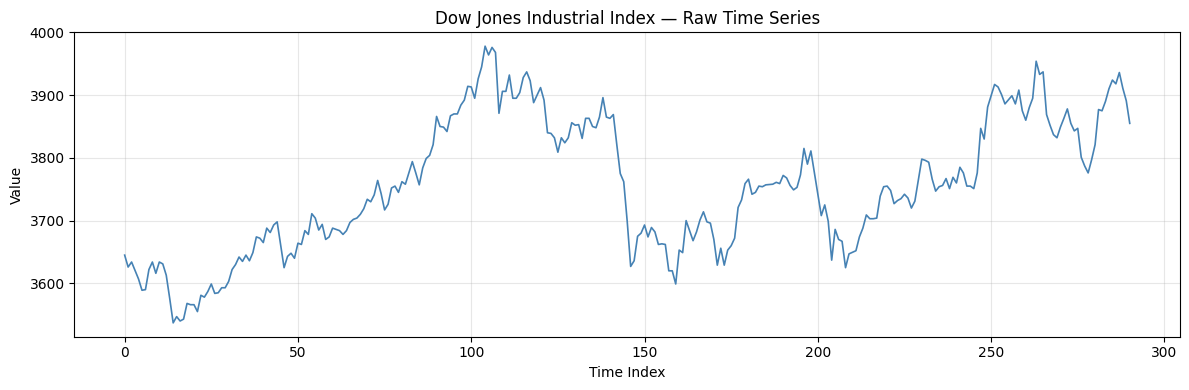

In [19]:
# ============================================================
# LOAD DATA
# ============================================================
# CSV file should be in the same directory as this notebook,
# OR update CSV_PATH below.

CSV_PATH = "content/monthly-closings-of-the-dowjones.csv"

series = pd.read_csv(CSV_PATH, header=0, parse_dates=[0], index_col=0)
raw_values = series.values.flatten().astype(np.float64)
print(f"Dataset: Dow Jones Industrial Index")
print(f"Data points: {len(raw_values)}")

# Plot raw data
plt.figure(figsize=(12, 4))
plt.plot(raw_values, color='steelblue', linewidth=1.2)
plt.title("Dow Jones Industrial Index — Raw Time Series")
plt.xlabel("Time Index")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# PREPROCESS DATA
# ============================================================
N_TEST = 60  # Last 60 samples for testing (same as LSTM-SNP)

X_train, y_train, X_test, y_test, scaler, raw_values = prepare_data(raw_values, n_test=N_TEST)

print(f"Train samples: {X_train.shape[0]}")
print(f"Test samples:  {X_test.shape[0]}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

Train samples: 230
Test samples:  60
X_train shape: (230, 1, 1)
X_test shape:  (60, 1, 1)


In [ ]:
# ============================================================
# RUN EXPERIMENT — 30 Independent Runs
# ============================================================
# Identical to LSTM-SNP protocol:
#   - 30 independent runs
#   - fresh model initialization each run
#   - 200 epochs per run
#   - Adam optimizer, MSE loss, batch_size=1, no shuffle

N_RUNS = 30
N_EPOCHS = 200
DEVICE = "cpu"

# Model hyperparameters
D_MODEL = 8      # matches LSTM-SNP hidden units
N_HEADS = 2
N_LAYERS = 1
FF_DIM = 16
T = 4            # spiking timesteps

all_run_metrics = []
all_predictions = []
all_losses = []

print(f"Configuration:")
print(f"  Runs: {N_RUNS}, Epochs: {N_EPOCHS}")
print(f"  d_model={D_MODEL}, n_heads={N_HEADS}, n_layers={N_LAYERS}")
print(f"  ff_dim={FF_DIM}, T={T}")
print(f"  Device: {DEVICE}")
print(f"{'='*60}")

for run_idx in range(N_RUNS):
    print(f"\nRun {run_idx+1}/{N_RUNS}", end=" — ", flush=True)
    start = time.time()

    # Create fresh model
    model = SpikingTransformerForecaster(
        input_dim=1, d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS,
        ff_dim=FF_DIM, T=T
    ).to(DEVICE)

    # Train
    losses = train_model(
        model, X_train, y_train, epochs=N_EPOCHS, lr=0.001,
        device=DEVICE, verbose=True
    )
    all_losses.append(losses)

    # Predict
    predictions, expected = rolling_predict(
        model, X_test, y_test, raw_values, scaler, n_test=N_TEST, device=DEVICE
    )

    # Metrics
    metrics = compute_metrics(predictions, expected)
    all_run_metrics.append(metrics)
    all_predictions.append(predictions)

    elapsed = time.time() - start
    print(f"RMSE: {metrics['rmse']:.4f}, MSE: {metrics['mse']:.4f}, "
          f"NMSE: {metrics['nmse']:.6f} ({elapsed:.1f}s)")

Configuration:
  Runs: 30, Epochs: 200
  d_model=8, n_heads=2, n_layers=1
  ff_dim=16, T=4
  Device: cpu

Run 1/30 —   Epoch 50/200 — Loss: 0.084061
  Epoch 100/200 — Loss: 0.081842
  Epoch 150/200 — Loss: 0.082740
  Epoch 200/200 — Loss: 0.083019
RMSE: 24.1975, MSE: 585.5205, NMSE: 0.158653 (124.8s)

Run 2/30 —   Epoch 50/200 — Loss: 0.084335
  Epoch 100/200 — Loss: 0.082656
  Epoch 150/200 — Loss: 0.082376
  Epoch 200/200 — Loss: 0.082898
RMSE: 24.3986, MSE: 595.2910, NMSE: 0.162765 (123.6s)

Run 3/30 —   Epoch 50/200 — Loss: 0.081882
  Epoch 100/200 — Loss: 0.083515
  Epoch 150/200 — Loss: 0.083606
  Epoch 200/200 — Loss: 0.082646
RMSE: 24.5490, MSE: 602.6511, NMSE: 0.162999 (123.0s)

Run 4/30 —   Epoch 50/200 — Loss: 0.084980
  Epoch 100/200 — Loss: 0.084698
  Epoch 150/200 — Loss: 0.084549
  Epoch 200/200 — Loss: 0.084307
RMSE: 24.0608, MSE: 578.9225, NMSE: 0.158716 (121.8s)

Run 5/30 —   Epoch 50/200 — Loss: 0.083913
  Epoch 100/200 — Loss: 0.084102
  Epoch 150/200 — Loss: 0.0828

In [ ]:
# ============================================================
# AGGREGATE RESULTS ACROSS 30 RUNS
# ============================================================
rmses = [m["rmse"] for m in all_run_metrics]
mses  = [m["mse"]  for m in all_run_metrics]
nmses = [m["nmse"] for m in all_run_metrics]

print(f"{'='*60}")
print(f"  RESULTS SUMMARY — Dow Jones Industrial Index")
print(f"{'='*60}")
print(f"  RMSE:  {np.mean(rmses):.6f} ± {np.std(rmses):.6f}")
print(f"  MSE:   {np.mean(mses):.6f} ± {np.std(mses):.6f}")
print(f"  NMSE:  {np.mean(nmses):.10f} ± {np.std(nmses):.10f}")
print(f"{'='*60}")
print(f"\n  Best  RMSE: {min(rmses):.6f}")
print(f"  Worst RMSE: {max(rmses):.6f}")

In [ ]:
# ============================================================
# VISUALIZATION
# ============================================================

# --- Best run predictions vs actuals ---
best_idx = np.argmin([m["rmse"] for m in all_run_metrics])
best_preds = all_predictions[best_idx]

plt.figure(figsize=(14, 6))
plt.plot(expected, label="Actual", color="blue", linewidth=1.5, marker="o", markersize=3)
plt.plot(best_preds, label=f"SNN-Transformer (Best Run, RMSE={all_run_metrics[best_idx]['rmse']:.4f})",
         color="red", linewidth=1.5, linestyle="dashed", marker="x", markersize=3)
plt.title(f"Dow Jones Industrial Index — Actual vs Predicted (Best Run)")
plt.xlabel("Test Sample Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Training loss convergence (best run) ---
plt.figure(figsize=(10, 4))
plt.plot(all_losses[best_idx], color="green", linewidth=0.8)
plt.title(f"Dow Jones Industrial Index — Training Loss (Best Run)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- RMSE distribution across runs ---
plt.figure(figsize=(8, 4))
plt.hist(rmses, bins=10, color="steelblue", edgecolor="white", alpha=0.8)
plt.axvline(np.mean(rmses), color="red", linestyle="dashed", label=f"Mean: {np.mean(rmses):.4f}")
plt.title(f"Dow Jones Industrial Index — RMSE Distribution (30 Runs)")
plt.xlabel("RMSE")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()